# Visualização da Tabela


In [26]:
# Ativa o recarregamento para não dar erro de cache
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import config_regras as regras
import plotly.express as px
import plotly.graph_objects as go


sys.path.append(os.path.abspath("../src"))
from queries import buscar_vendas_gerais, buscar_custos_operacionais

df_vendas = buscar_vendas_gerais()
df_custos = buscar_custos_operacionais()

c:\Users\igor.de.paula\dashInsights\src\queries.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)
c:\Users\igor.de.paula\dashInsights\src\queries.py:57: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


In [28]:
import config_regras as regras

# 1. Criamos a coluna 'mes_referencia' no DF de vendas (Formato YYYY-MM)
df_vendas['mes_referencia'] = df_vendas['data_venda'].dt.to_period('M').astype(str)

# 2. Mapeamos o CAC dinamicamente baseado no canal de aquisição
df_vendas['custo_cac'] = df_vendas['canal_aquisicao'].map(regras.CAC_POR_CANAL)

# 3. Faturamento Bruto Comercial (Apenas quem não está inadimplente)
faturamento_bruto = df_vendas[df_vendas['inadimplente'] == False]['valor_pago'].sum()

# =========================================================================
# LENDO AS REGRAS FISCAIS DO ARQUIVO DE CONFIGURAÇÃO CENTRALIZADO
# =========================================================================
# Impostos recalculados dinamicamente pela constante do config_regras
impostos_deducoes = faturamento_bruto * regras.ALIQUOTA_IMPOSTO

# Faturamento Líquido Real
faturamento_liquido = faturamento_bruto - impostos_deducoes

# Custo de Entrega (COGS) recalculado pela constante
custo_cogs = faturamento_bruto * regras.TAXA_COGS

# 4. Investimento Total em Marketing (Soma de todos os CACs)
total_investimento_marketing = df_vendas['custo_cac'].sum()

# 5. Custo Operacional Fixo de Estrutura (OpEx vindo do banco de dados)
custo_opex_total = df_custos['valor_custo'].sum()

# 6. Cálculo do Lucro Líquido Real Corporativo
lucro_real = faturamento_liquido - (custo_cogs + custo_opex_total + total_investimento_marketing)

# --- EXIBIÇÃO DO DRE OFICIAL ---
print("📊 ======================================================= 📊")
print("💵      DEMONSTRATIVO DE RESULTADOS (DRE PARAMETRIZADA)    💵")
print("📊 ======================================================= 📊\n")
print(f"💰 (+) FATURAMENTO BRUTO:          R$ {faturamento_bruto:,.2f}")
print(f"💸 (-) Impostos e Deduções ({regras.ALIQUOTA_IMPOSTO*100:.0f}%): R$ {impostos_deducoes:,.2f}")
print(f"🌍 (=) FATURAMENTO LÍQUIDO:        R$ {faturamento_liquido:,.2f}\n")
print(f"📦 (-) Custo de Entrega (COGS {regras.TAXA_COGS*100:.0f}%):R$ {custo_cogs:,.2f}")
print(f"📢 (-) Investimento Marketing(CAC):R$ {total_investimento_marketing:,.2f}")
print(f"📉 (-) Custo Fixo de OpEx (Banco): R$ {custo_opex_total:,.2f}\n")
print(f"🚀 (=) LUCRO LÍQUIDO REAL:         R$ {lucro_real:,.2f}")

margem_lucro = (lucro_real / faturamento_bruto) * 100 if faturamento_bruto > 0 else 0
print(f"📊 (%) Margem Líquida Real:        {margem_lucro:.2f}%\n")
print("📊 ======================================================= 📊")

📊 ======================================================= 📊
💵      DEMONSTRATIVO DE RESULTADOS (DRE PARAMETRIZADA)    💵
📊 ======================================================= 📊

💰 (+) FATURAMENTO BRUTO:          R$ 65,760,000.00
💸 (-) Impostos e Deduções (14%): R$ 9,206,400.00
🌍 (=) FATURAMENTO LÍQUIDO:        R$ 56,553,600.00

📦 (-) Custo de Entrega (COGS 15%):R$ 9,864,000.00
📢 (-) Investimento Marketing(CAC):R$ 2,945,800.00
📉 (-) Custo Fixo de OpEx (Banco): R$ 12,555,000.00

🚀 (=) LUCRO LÍQUIDO REAL:         R$ 31,188,800.00
📊 (%) Margem Líquida Real:        47.43%

📊 ======================================================= 📊


C:\Users\igor.de.paula\AppData\Local\Temp\ipykernel_14452\1029165311.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\igor.de.paula\AppData\Local\Temp\ipykernel_14452\1029165311.py:62: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\igor.de.paula\dashInsights\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


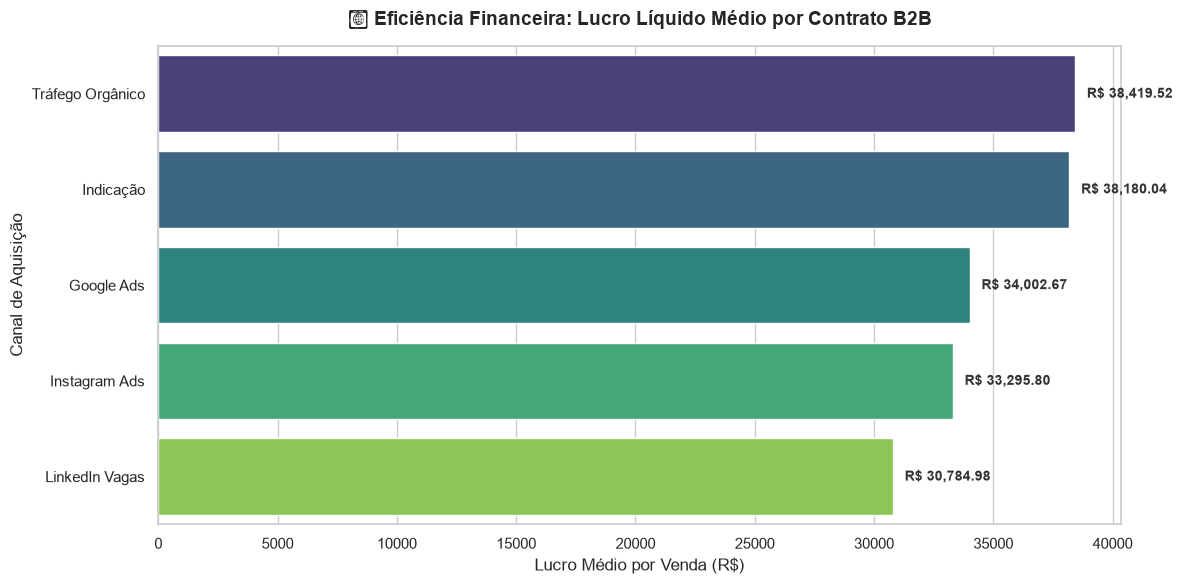

In [29]:
# Configuração visual do Seaborn e Matplotlib para o modo executivo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# =========================================================================
# 1. PREPARAÇÃO MINUCIOSA DOS DADOS (PANDAS)
# =========================================================================
# Criamos uma cópia para não afetar os DataFrames originais
df_analise = df_vendas.copy()

# A) Mapeamos o CAC de cada contrato individualmente
df_analise['custo_cac'] = df_analise['canal_aquisicao'].map(regras.CAC_POR_CANAL)

# B) Calculamos o Imposto individual de cada venda (14%)
df_analise['imposto_venda'] = df_analise['valor_pago'] * regras.ALIQUOTA_IMPOSTO

# C) Calculamos o Custo de Entrega individual (COGS - 15%)
df_analise['cogs_venda'] = df_analise['valor_pago'] * regras.TAXA_COGS

# D) Se o cliente estiver inadimplente, o faturamento real é 0, mas o CAC e o COGS continuam existindo!
df_analise['faturamento_real_venda'] = df_analise.apply(
    lambda row: row['valor_pago'] if not row['inadimplente'] else 0.0, axis=1
)

# E) Calculamos a Margem de Contribuição individual de cada linha (Faturamento - Imposto - COGS - CAC)
df_analise['lucro_unitario'] = df_analise['faturamento_real_venda'] - (df_analise['imposto_venda'] + df_analise['cogs_venda'] + df_analise['custo_cac'])

# =========================================================================
# 2. ANÁLISE CIENTÍFICA: QUAL CANAL DE MARKETING É MAIS LUCRATIVO?
# =========================================================================
# Agrupamos por canal de aquisição para entender onde o dinheiro rende mais
analise_canais = df_analise.groupby('canal_aquisicao').agg(
    total_vendas=('id_venda', 'count'),
    faturamento_bruto=('faturamento_real_venda', 'sum'),
    lucro_gerado=('lucro_unitario', 'sum')
).reset_index()

# Criamos uma métrica de eficiência: Lucro Médio por Contrato
analise_canais['lucro_medio_por_venda'] = analise_canais['lucro_gerado'] / analise_canais['total_vendas']
analise_canais = analise_canais.sort_values(by='lucro_medio_por_venda', ascending=False)

# =========================================================================
# 3. PLOTANDO COM SEABORN
# =========================================================================
ax = sns.barplot(
    data=analise_canais, 
    x='lucro_medio_por_venda', 
    y='canal_aquisicao', 
    palette='viridis'
)

plt.title('📊 Eficiência Financeira: Lucro Líquido Médio por Contrato B2B', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Lucro Médio por Venda (R$)', fontsize=12)
plt.ylabel('Canal de Aquisição', fontsize=12)

# Adiciona os valores monetários nas barras para facilitar a leitura da diretoria
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 500, p.get_y() + p.get_height()/2, f"R$ {width:,.2f}", 
            va='center', ha='left', fontsize=10, fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

In [30]:
    # Formatando a tabela para exibição executiva (apenas colunas de interesse)
    tabela_dre_canais = analise_canais[[
        'canal_aquisicao', 
        'total_vendas', 
        'faturamento_bruto', 
        'lucro_gerado', 
        'lucro_medio_por_venda'
    ]].copy()

    # Renomeando colunas para ficar elegante na leitura
    tabela_dre_canais.columns = [
        'Canal de Aquisição', 
        'Qtd Vendas', 
        'Fat. Bruto (Total)', 
        'Lucro Líquido (Total)', 
        'Lucro Médio por Contrato'
    ]

    # Aplicando formatação monetária para facilitar a análise
    tabela_formatada = tabela_dre_canais.style.format({
        'Fat. Bruto (Total)': 'R$ {:,.2f}',
        'Lucro Líquido (Total)': 'R$ {:,.2f}',
        'Lucro Médio por Contrato': 'R$ {:,.2f}'
    }).background_gradient(subset=['Lucro Médio por Contrato'], cmap='Greens')

    # Exibir a tabela
    display(tabela_formatada)

,Canal de Aquisição,Qtd Vendas,Fat. Bruto (Total),Lucro Líquido (Total),Lucro Médio por Contrato
4,Tráfego Orgânico,228,"R$ 12,795,000.00","R$ 8,759,650.00","R$ 38,419.52"
1,Indicação,268,"R$ 15,115,000.00","R$ 10,232,250.00","R$ 38,180.04"
0,Google Ads,225,"R$ 12,385,000.00","R$ 7,650,600.00","R$ 34,002.67"
2,Instagram Ads,226,"R$ 11,990,000.00","R$ 7,524,850.00","R$ 33,295.80"
3,LinkedIn Vagas,253,"R$ 13,475,000.00","R$ 7,788,600.00","R$ 30,784.98"


In [31]:
# =========================================================================
# MEMÓRIA DE CÁLCULO: AUDITORIA DOS DADOS (TOTALIZADORES)
# =========================================================================

# Descobrimos quantos meses existem na base de dados selecionada para o OpEx acompanhar
df_analise['mes_ref'] = df_analise['data_venda'].dt.to_period('M').astype(str)
meses_ativos = max(df_analise['mes_ref'].nunique(), 1)

# Calculamos o custo mensal base (Folha + Infra do banco de dados) e multiplicamos pelos meses ativos
custo_opex_mensal = df_custos['valor_custo'].sum() / 18  # Escopo total do nosso banco (18 meses)
custo_opex_proporcional = custo_opex_mensal * meses_ativos

# 1. Totalizadores de Massa (Somas brutas)
total_vendas_realizadas = df_analise['faturamento_real_venda'].sum()
total_impostos = df_analise['imposto_venda'].sum()
total_cogs = df_analise['cogs_venda'].sum()
total_cac = df_analise['custo_cac'].sum()
total_opex = custo_opex_proporcional 

# 2. Construção da Tabela de Auditoria
dados_auditoria = {
    "Conceito": [
        "Faturamento Bruto (Real)", 
        "(-) Impostos (14%)", 
        "(=) Receita Líquida", 
        "(-) COGS (Entrega 15%)", 
        "(-) Marketing (CAC Total)", 
        "(-) OpEx (Fixo Estrutural)", 
        "(=) LUCRO LÍQUIDO REAL"
    ],
    "Valor (R$)": [
        total_vendas_realizadas,
        -total_impostos,
        (total_vendas_realizadas - total_impostos),
        -total_cogs,
        -total_cac,
        -total_opex,
        (total_vendas_realizadas - total_impostos - total_cogs - total_cac - total_opex)
    ]
}

df_auditoria = pd.DataFrame(dados_auditoria)

# 3. Exibição da tabela de veracidade
styler = df_auditoria.style.format({'Valor (R$)': 'R$ {:,.2f}'})
display(styler)

,Conceito,Valor (R$)
0,Faturamento Bruto (Real),"R$ 65,760,000.00"
1,(-) Impostos (14%),"R$ -10,069,500.00"
2,(=) Receita Líquida,"R$ 55,690,500.00"
3,(-) COGS (Entrega 15%),"R$ -10,788,750.00"
4,(-) Marketing (CAC Total),"R$ -2,945,800.00"
5,(-) OpEx (Fixo Estrutural),"R$ -9,067,500.00"
6,(=) LUCRO LÍQUIDO REAL,"R$ 32,888,450.00"


In [32]:
# =========================================================================
# MÉTRICA DE VOLUME: TOTAL DE CONTRATOS FECHADOS (AUDITORIA)
# =========================================================================

# Matematicamente, o total de contratos é a contagem de linhas do nosso DataFrame filtrado.
# Cada linha representa um contrato único assinado e registrado.
total_contratos = int(df_analise.shape[0])

# Criando uma exibição elegante e limpa para o laboratório
print("=" * 50)
print(f"📋 TOTAL DE CONTRATOS FECHADOS: {total_contratos:,}".replace(",", "."))
print("=" * 50)

# Verificação de segurança (Auditoria): Garantir que não estamos contando uma base vazia
assert total_contratos > 0, "Alerta: A base de dados selecionada não possui contratos registrados!"

📋 TOTAL DE CONTRATOS FECHADOS: 1.200


In [33]:
# =========================================================================
# MODO INFO & RECONHECIMENTO DE ESTRUTURA (RAIO-X DO BANCO)
# =========================================================================

print("🔍 [MODO INFO] — RECONHECENDO A TABELA DE VENDAS COMPREENSIVA (df_analise)")
print("-" * 80)
# O .info() nos diz o nome exato de cada coluna, se há valores nulos e o tipo de dado
df_analise.info()

print("\n" + "="*80 + "\n")

print("📋 [MODO SIMPLES] — VISUALIZANDO AS 3 PRIMEIRAS LINHAS DE VENDAS")
print("-" * 80)
# O .head(3) nos dá uma amostra visual rápida dos dados reais para checarmos a grafia
display(df_analise.head(3))

print("\n" + "="*80 + "\n")

print("💼 [MODO INFO] — RECONHECENDO A TABELA DE CUSTOS FIXOS (df_custos ou df_bruto_custos)")
print("-" * 80)
# Se você tiver a tabela de custos carregada, vamos ver a cara dela também
try:
    df_custos.info()
    print("-" * 80)
    display(df_custos.head(3))
except NameError:
    try:
        df_bruto_custos.info()
        print("-" * 80)
        display(df_bruto_custos.head(3))
    except NameError:
        print("Aviso: Tabela de custos fixos ainda não foi declarada com o nome 'df_custos' ou 'df_bruto_custos' neste escopo.")

🔍 [MODO INFO] — RECONHECENDO A TABELA DE VENDAS COMPREENSIVA (df_analise)
--------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype        
---  ------                  --------------  -----        
 0   id_venda                1200 non-null   int64        
 1   nome_aluno              1200 non-null   str          
 2   email                   1200 non-null   str          
 3   idade                   1200 non-null   int64        
 4   genero                  1200 non-null   str          
 5   estado                  1200 non-null   str          
 6   plano                   1200 non-null   str          
 7   valor_pago              1200 non-null   float64      
 8   forma_pagamento         1200 non-null   str          
 9   quantidade_parcelas     1200 non-null   int64        
 10  canal_aquisicao         1200 non-nul

,id_venda,nome_aluno,email,idade,genero,estado,plano,valor_pago,forma_pagamento,quantidade_parcelas,...,nota_nps,inadimplente,data_venda,mes_referencia,custo_cac,imposto_venda,cogs_venda,faturamento_real_venda,lucro_unitario,mes_ref
0,1,Pedro Lucas Nunes,gomesmanuela_0@live.com,54,Masculino,RJ,Prata,45000.0,Parcelado Cartão,8,...,6,False,2025-10-16,2025-10,0.0,6300.0,6750.0,45000.0,31950.0,2025-10
1,2,Ana Luiza Leão,acasa-grande_1@yahoo.com.br,52,Feminino,SP,Diamante,100000.0,Parcelado Cartão,12,...,1,False,2025-12-26,2025-12,3500.0,14000.0,15000.0,100000.0,67500.0,2025-12
2,3,Lorenzo Vieira,casa-grandeluisa_2@uol.com.br,45,Feminino,SC,Diamante,100000.0,Parcelado Boleto,6,...,1,False,2025-10-06,2025-10,3500.0,14000.0,15000.0,100000.0,67500.0,2025-10




💼 [MODO INFO] — RECONHECENDO A TABELA DE CUSTOS FIXOS (df_custos ou df_bruto_custos)
--------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_custo        252 non-null    int64  
 1   mes_referencia  252 non-null    str    
 2   categoria       252 non-null    str    
 3   descricao       252 non-null    str    
 4   valor_custo     252 non-null    float64
dtypes: float64(1), int64(1), str(3)
memory usage: 25.4 KB
--------------------------------------------------------------------------------


,id_custo,mes_referencia,categoria,descricao,valor_custo
0,1,2025-01,Folha de Pagamento,Diretoria Executiva (C-Level),85000.0
1,2,2025-01,Folha de Pagamento,Gerentes de Vendas e CS (3 pessoas),45000.0
2,3,2025-01,Folha de Pagamento,Closers / Executivos de Contas (15 pessoas),105000.0


In [34]:
# =========================================================================
# DRE VERTICAL INTEGRAL — MERCADO REAL (VENDAS + CUSTOS FIXOS)
# =========================================================================

# 1. Parte Comercial (DataFrame de Vendas: df_analise)
faturamento_bruto = df_analise[df_analise['inadimplente'] == False]['valor_pago'].sum()
total_impostos = df_analise[df_analise['inadimplente'] == False]['imposto_venda'].sum()
receita_liquida = faturamento_bruto - total_impostos

# 2. Custos Variáveis (COGS de 15% + CAC Real)
TAXA_COGS = 0.15
total_cogs = faturamento_bruto * TAXA_COGS
total_cac_marketing = df_analise['custo_cac'].sum()

# 3. Custos Fixos (DataFrame de Custos: usando o valor_custo que você acabou de mapear)
# Calculamos o total de custos fixos acumulados na base
total_opex_fixo = df_custos['valor_custo'].sum()

# 4. Lucro Real Final (Dinheiro que sobra pro dono)
lucro_liquido_real = receita_liquida - (total_cogs + total_cac_marketing + total_opex_fixo)

# =========================================================================
# RELATÓRIO EXECUTIVO INTEGRADO
# =========================================================================
print("📋 DRE VERTICAL COMPLETA — LABORATÓRIO DE AUDITORIA")
print("=" * 65)
print(f"💰 (+) FATURAMENTO BRUTO:            R$ {faturamento_bruto:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
print(f"💸 (-) IMPOSTOS REAL (14%):          -R$ {total_impostos:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
print(f"🌍 (=) RECEITA LÍQUIDA:               R$ {receita_liquida:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
print(f"📦 (-) COGS ENTREGA (15%):            -R$ {total_cogs:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
print(f"📢 (-) MARKETING (CAC Total):         -R$ {total_cac_marketing:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
print(f"📉 (-) CUSTO FIXO TOTAL (OpEx):       -R$ {total_opex_fixo:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
print("-" * 65)
print(f"🚀 (=) LUCRO LÍQUIDO REAL:            R$ {lucro_liquido_real:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
print("=" * 65)

📋 DRE VERTICAL COMPLETA — LABORATÓRIO DE AUDITORIA
💰 (+) FATURAMENTO BRUTO:            R$ 65.760.000,00
💸 (-) IMPOSTOS REAL (14%):          -R$ 9.206.400,00
🌍 (=) RECEITA LÍQUIDA:               R$ 56.553.600,00
📦 (-) COGS ENTREGA (15%):            -R$ 9.864.000,00
📢 (-) MARKETING (CAC Total):         -R$ 2.945.800,00
📉 (-) CUSTO FI.O TOTAL (OpEx):       -R$ 12.555.000,00
-----------------------------------------------------------------
🚀 (=) LUCRO LÍQUIDO REAL:            R$ 31.188.800,00


In [35]:
# =========================================================================
# LABORATÓRIO DE AUDITORIA: CÁLCULO DO TICKET MÉDIO REAL (PANDAS PURÃO)
# =========================================================================

# 1. Isolamos apenas os contratos válidos (ignorando inadimplentes)
df_contratos_pagos = df_analise[df_analise['inadimplente'] == False]

# 2. Executamos as agregações matemáticas necessárias
faturamento_comercial_total = df_contratos_pagos['valor_pago'].sum()
quantidade_contratos_ativos = len(df_contratos_pagos)

# 3. Aplicamos a fórmula de eficiência do Ticket Médio
if quantidade_contratos_ativos > 0:
    ticket_medio_calculado = faturamento_comercial_total / quantidade_contratos_ativos
else:
    ticket_medio_calculado = 0.0

# =========================================================================
# RELATÓRIO DE VALIDAÇÃO DOS NÚMEROS
# =========================================================================
print("🔬 VALIDAÇÃO EXPERIMENTAL DO TICKET MÉDIO")
print("-" * 50)
print(f"📦 Contratos Adimplentes Analisados:   {quantidade_contratos_ativos} contratos")
print(f"💰 Faturamento Comercial Computado:    R$ {faturamento_comercial_total:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
print(f"🎯 TICKET MÉDIO POR CONTRATO:          R$ {ticket_medio_calculado:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
print("-" * 50)

🔬 VALIDAÇÃO EXPERIMENTAL DO TICKET MÉDIO
--------------------------------------------------
📦 Contratos Adimplentes Analisados:   1091 contratos
💰 Faturamento Comercial Computado:    R$ 65.760.000,00
🎯 TICKET MÉDIO POR CONTRATO:          R$ 60.274,98
--------------------------------------------------


C:\Users\igor.de.paula\AppData\Local\Temp\ipykernel_14452\1853646999.py:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\igor.de.paula\dashInsights\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


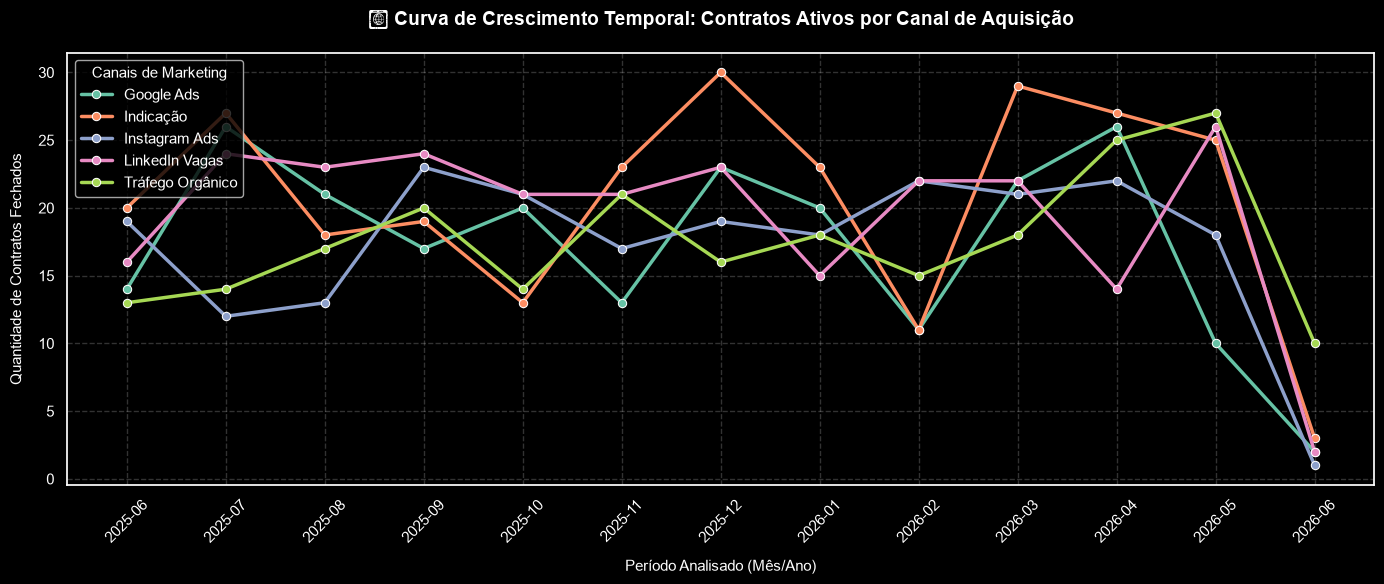

In [37]:
# =========================================================================
# LABORATÓRIO: ANÁLISE TEMPORAL DE CRESCIMENTO DE CONTRATOS POR CANAL
# =========================================================================

# 1. Garantir que a coluna de data está no formato correto e extrair o Ano-Mês
df_analise['mes_ano'] = df_analise['data_venda'].dt.to_period('M').astype(str)

# 2. Agrupar os dados para contar quantos contratos (vendas) entraram por mês por canal
evolucao_temporal = df_analise.groupby(['mes_ano', 'canal_aquisicao']).size().reset_index(name='qtd_contratos')

# 3. Configurar o estilo visual Dark do Gráfico
plt.style.use('dark_background')
plt.figure(figsize=(14, 6))

# 4. Plotar a linha de evolução de cada canal usando o Seaborn
sns.lineplot(
    data=evolucao_temporal, 
    x='mes_ano', 
    y='qtd_contratos', 
    hue='canal_aquisicao', 
    marker='o',          # Bolinha em cada ponto do mês
    linewidth=2.5,       # Espessura da linha
    palette='Set2'       # Paleta de cores elegantes
)

# =========================================================================
# LAPIDAÇÃO ESTÉTICA DO GRÁFICO (REVISÃO DOBRADA)
# =========================================================================
plt.title('📈 Curva de Crescimento Temporal: Contratos Ativos por Canal de Aquisição', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Período Analisado (Mês/Ano)', fontsize=11, labelpad=10)
plt.ylabel('Quantidade de Contratos Fechados', fontsize=11, labelpad=10)

# Rotacionar as datas do eixo X para não embolar a leitura
plt.xticks(rotation=45)

# Customizar a legenda lateral de canais
plt.legend(title='Canais de Marketing', title_fontsize='11', loc='upper left')

# Adicionar linhas de grade discretas ao fundo para facilitar a leitura de metas
plt.grid(True, linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

In [39]:
# 1.1 Criamos uma cópia de segurança para não afetar o DataFrame principal
df_temporal = df_analise.copy()

# 1.2 Forçamos a coluna a ser do tipo Datetime (padrão de segurança)
df_temporal['data_venda'] = pd.to_datetime(df_temporal['data_venda'])

# 1.3 Extração por DIA: Formato Ano-Mês-Dia (Ex: 2026-06-13)
df_temporal['Apenas_Dia'] = df_temporal['data_venda'].dt.strftime('%Y-%m-%d')

# 1.4 Extração por SEMANA: Identifica o ano e o número sequencial da semana (Ex: 2026-Semana 24)
df_temporal['Ano_Semana'] = df_temporal['data_venda'].dt.strftime('%Y-Semana %W')

In [40]:
# 2.1 Agrupamos por Dia e Canal, contando o volume absoluto de ocorrências
tabela_diaria = df_temporal.groupby(['Apenas_Dia', 'canal_aquisicao']).size().reset_index(name='Contratos')

# 2.2 Ordenamos a tabela cronologicamente para a linha do gráfico não andar para trás
tabela_diaria = tabela_diaria.sort_values('Apenas_Dia')

# 2.3 Visualização de teste: Vamos checar as 10 primeiras linhas dessa estrutura
print("📊 ESTRUTURA DA TABELA TEMPORAL DIÁRIA (TOP 10):")
print("-" * 60)
print(tabela_diaria.head(10))
print("-" * 60)

📊 ESTRUTURA DA TABELA TEMPORAL DIÁRIA (TOP 10):
------------------------------------------------------------
   Apenas_Dia   canal_aquisicao  Contratos
0  2025-06-07        Google Ads          1
1  2025-06-07  Tráfego Orgânico          2
2  2025-06-08        Google Ads          1
3  2025-06-08     Instagram Ads          1
4  2025-06-09        Google Ads          1
5  2025-06-09         Indicação          3
6  2025-06-09     Instagram Ads          1
7  2025-06-10         Indicação          1
8  2025-06-10    LinkedIn Vagas          2
9  2025-06-10  Tráfego Orgânico          1
------------------------------------------------------------


In [57]:
# =========================================================================
# TASK 5.3.3: RENDERIZAÇÃO DA CURVA TEMPORAL COM FILTRO DROP_DOWN COMPACTO
# =========================================================================
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd

# 1. ENGENHARIA DE DADOS: Criando as 3 visões temporais antes do gráfico
df_temporal = df_analise.copy()
df_temporal['data_venda'] = pd.to_datetime(df_temporal['data_venda'])

# Extraímos as chaves textuais de tempo
df_temporal['Visao_Dia'] = df_temporal['data_venda'].dt.strftime('%Y-%m-%d')
df_temporal['Visao_Semana'] = df_temporal['data_venda'].dt.strftime('%Y-Sem %W')
df_temporal['Visao_Mes'] = df_temporal['data_venda'].dt.strftime('%Y-%m')

# Agrupamos as 3 tabelas que os botões vão alternar
df_dia = df_temporal.groupby(['Visao_Dia', 'canal_aquisicao']).size().reset_index(name='Contratos').sort_values('Visao_Dia')
df_semana = df_temporal.groupby(['Visao_Semana', 'canal_aquisicao']).size().reset_index(name='Contratos').sort_values('Visao_Semana')
df_mes = df_temporal.groupby(['Visao_Mes', 'canal_aquisicao']).size().reset_index(name='Contratos').sort_values('Visao_Mes')

# =========================================================================
# 2. CONSTRUÇÃO DO GRÁFICO (Injetando as Linhas Suaves sem marcadores)
# =========================================================================
lista_canais = df_temporal['canal_aquisicao'].unique()
num_canais = len(lista_canais)
fig_diario = go.Figure()

# 🔹 BLOCO A: Dados DIÁRIOS (Ativos por padrão: visible=True)
for canal in lista_canais:
    df_c = df_dia[df_dia['canal_aquisicao'] == canal]
    fig_diario.add_trace(go.Scatter(
        x=df_c['Visao_Dia'], y=df_c['Contratos'], name=canal, 
        mode='lines', line_shape='spline', visible=True,
        fill='tozeroy', fillcolor='rgba(0, 242, 254, 0.05)'
    ))

# 🔹 BLOCO B: Dados SEMANAIS (Escondidos por padrão: visible=False)
for canal in lista_canais:
    df_c = df_semana[df_semana['canal_aquisicao'] == canal]
    fig_diario.add_trace(go.Scatter(
        x=df_c['Visao_Semana'], y=df_c['Contratos'], name=canal, 
        mode='lines', line_shape='spline', visible=False,
        fill='tozeroy', fillcolor='rgba(0, 242, 254, 0.05)'
    ))

# 🔹 BLOCO C: Dados MENSAL (Escondidos por padrão: visible=False)
for canal in lista_canais:
    df_c = df_mes[df_mes['canal_aquisicao'] == canal]
    fig_diario.add_trace(go.Scatter(
        x=df_c['Visao_Mes'], y=df_c['Contratos'], name=canal, 
        mode='lines', line_shape='spline', visible=False,
        fill='tozeroy', fillcolor='rgba(0, 242, 254, 0.05)'
    ))

# =========================================================================
# 3. LAPIDAÇÃO CIRÚRGICA DO LAYOUT (MÁXIMA LARGURA E FILTRO PEQUENO)
# =========================================================================
fig_diario.update_layout(
    title=dict(text='📈 Evolução Temporal de Contratos por Canal', pad=dict(b=20)),
    template='plotly_dark',
    width=800,                  # Força o gráfico a abrir o máximo possível na horizontal
    height=500,                  
    legend_title='Canais de Marketing',
    hovermode='x unified',
    font=dict(family='sans-serif', size=12),
    
    # Colamos o gráfico nas bordas (l=20) e abrimos o topo (t=120) para o menu e título deitado
    margin=dict(l=20, r=20, t=120, b=60), 
    
    xaxis=dict(tickangle=45),
    yaxis=dict(title=None),      # Remove o título vertical para liberar espaço
    
    # Título do Eixo Y deitado na horizontal acima do gráfico
    annotations=[
        dict(
            text="👤 Volume de Contratos Fechados",
            xref="paper", yref="paper",
            x=0.0, y=1.12,
            showarrow=False,
            font=dict(family="sans-serif", size=12, color="#8A9299"),
            align="left"
        )
    ],
    
    # 💡 SEU NOVO FILTRO COMPACTO (DROPDOWN)
    updatemenus=[
        dict(
            type="dropdown",         # ✨ Alterado de "buttons" para "dropdown" (Cria a caixinha retrátil)
            direction="down",        # ✨ Abre a lista para baixo ao clicar
            active=0,                # Visão Diária começa selecionada
            x=0.85, y=1.22,          # Posiciona o filtro de forma limpa no topo superior direito
            bgcolor="#1C1F26",       # Cor de fundo combinando com nosso dark mode
            font=dict(color="#FFFFFF", size=11),
            buttons=list([
                dict(label="☀️ Escopo: Dia a Dia", method="update",
                     args=[{"visible": [True]*num_canais + [False]*num_canais + [False]*num_canais},
                           {"xaxis": {"title": "Cronologia (Dia a Dia)", "tickangle": 45}}]),
                
                dict(label="📆 Escopo: Semanal", method="update",
                     args=[{"visible": [False]*num_canais + [True]*num_canais + [False]*num_canais},
                           {"xaxis": {"title": "Cronologia (Semanas do Ano)", "tickangle": 45}}]),
                
                dict(label="📅 Escopo: Mensal", method="update",
                     args=[{"visible": [False]*num_canais + [False]*num_canais + [True]*num_canais},
                           {"xaxis": {"title": "Cronologia (Meses Consolidados)", "tickangle": 45}}]),
            ]),
        )
    ]
)

# Linhas de grade limpas
fig_diario.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#333')
fig_diario.update_yaxes(showgrid=True, gridwidth=1, gridcolor='#333')

# Exibir o gráfico no Notebook
fig_diario.show()